# Time-aware Visuelle 2.0 demand forecasting

**Owner:** Nilakshi  
**Module:** CCS4310 – Deep Learning  

This notebook reads only disk artifacts from preprocessing. It supports the saved `short_observation` or `cold_start` mode, selects models using validation only, protects the untouched test split during development, and performs final test evaluation only in an explicit full evaluation run. SHAP explainability is left to Dewmi.

In [8]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
RANDOM_STATE=42; FAST_DEV_RUN = False; FINAL_EVALUATION = True
if FINAL_EVALUATION and FAST_DEV_RUN:
    raise ValueError('FINAL_EVALUATION requires FAST_DEV_RUN=False')
RUN_TYPE='fast_dev' if FAST_DEV_RUN else 'full'
class HistoricalMeanRegressor(BaseEstimator, RegressorMixin):
    def fit(self,X,y): self.mean_=float(np.asarray(y).mean()); return self
    def predict(self,X): return np.repeat(self.mean_,len(X))
def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p/'data'/'interim').is_dir(): return p
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); DATA=ROOT/'data'/'interim'; MODEL_DIR=ROOT/'models'/'demand'; METRIC_DIR=ROOT/'outputs'/'metrics'; FIG_DIR=ROOT/'outputs'/'figures'
MODEL_DIR.mkdir(parents=True,exist_ok=True); METRIC_DIR.mkdir(parents=True,exist_ok=True); FIG_DIR.mkdir(parents=True,exist_ok=True)
print('Using the existing shared project kernel; no notebook package installation is performed.')
print('DEVELOPMENT / PIPELINE VALIDATION RESULTS ONLY' if RUN_TYPE=='fast_dev' else 'FULL RUN; final test evaluation is enabled only when FINAL_EVALUATION=True')

Using the existing shared project kernel; no notebook package installation is performed.
FULL RUN; final test evaluation is enabled only when FINAL_EVALUATION=True


## Load persisted splits and validate

In [2]:
required=['visuelle_demand_train.csv','visuelle_demand_validation.csv','visuelle_demand_test.csv','visuelle_demand_feature_config.json']
for f in required: assert (DATA/f).is_file(), f'Missing {DATA/f}; run preprocessing first.'
train=pd.read_csv(DATA/required[0],parse_dates=['time']); valid=pd.read_csv(DATA/required[1],parse_dates=['time']); test=pd.read_csv(DATA/required[2],parse_dates=['time']); cfg=json.loads((DATA/required[3]).read_text())
target=cfg['target_column']; features=cfg['feature_columns']; forbidden=set(cfg['identifier_columns'])
assert target in train and set(features).issubset(train.columns)
assert not forbidden.intersection(features),f'Raw identifiers leaked into predictive features: {forbidden.intersection(features)}'
assert train.time.max()<valid.time.min()<test.time.min()
if 'season_from_time' in cfg['time_features']: assert 'season_from_time' in cfg['categorical_features'] and 'season_from_time' in features
print('mode:',cfg['forecast_mode'],'time unit:',cfg['time_unit'],'run_type:',RUN_TYPE); print({k:len(v) for k,v in [('train',train),('validation',valid),('test',test)]})
for name,df in [('train',train),('validation',valid),('test',test)]: print(name,'range=',df.time.min(),'to',df.time.max(),'unique products=',df.external_code.nunique() if 'external_code' in df else 'n/a')
if 'external_code' in train: print('product overlaps:',len(set(train.external_code)&set(valid.external_code)),len(set(valid.external_code)&set(test.external_code)))

mode: short_observation time unit: week run_type: full
{'train': 794042, 'validation': 262417, 'test': 222355}
train range= 2016-11-28 00:00:00 to 2019-03-18 00:00:00 unique products= 3916
validation range= 2019-03-25 00:00:00 to 2019-09-16 00:00:00 unique products= 1407
test range= 2019-09-23 00:00:00 to 2020-03-16 00:00:00 unique products= 1045
product overlaps: 483 530


## Safe preprocessing, baselines, and candidate models

In [3]:
def cap(df,n): return df.sort_values('time').tail(n).copy() if FAST_DEV_RUN and len(df)>n else df
train,valid,test=cap(train,100000),cap(valid,30000),cap(test,30000)
Xtr,ytr=train[features],train[target]; Xv,yv=valid[features],valid[target]
cat=[c for c in cfg['categorical_features'] if c in features]; num=[c for c in cfg['numerical_features'] if c in features]
prep=ColumnTransformer([('num',SimpleImputer(strategy='median'),num),('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat)],remainder='drop')
models={'Linear Regression':Pipeline([('prep',prep),('model',LinearRegression())]),'Random Forest':Pipeline([('prep',prep),('model',RandomForestRegressor(n_estimators=100 if FAST_DEV_RUN else 300,random_state=RANDOM_STATE,n_jobs=-1,max_depth=18))] )}
try:
    from xgboost import XGBRegressor
    models['XGBoost']=Pipeline([('prep',prep),('model',XGBRegressor(n_estimators=150 if FAST_DEV_RUN else 400,max_depth=6,learning_rate=.05,subsample=.8,colsample_bytree=.8,random_state=RANDOM_STATE,n_jobs=2,objective='reg:squarederror'))])
except ImportError: print('Optional dependency xgboost is not installed in the current project environment.')
try:
    from lightgbm import LGBMRegressor
    models['LightGBM']=Pipeline([('prep',prep),('model',LGBMRegressor(n_estimators=150 if FAST_DEV_RUN else 400,learning_rate=.05,num_leaves=31,random_state=RANDOM_STATE,n_jobs=2,verbosity=-1))])
except ImportError: print('Optional dependency lightgbm is not installed in the current project environment.')
print('categorical features:',cat); print('numerical features:',num)
import time
from tqdm.auto import tqdm


categorical features: ['season', 'season_from_time', 'category', 'color', 'fabric', 'shop_label']
numerical features: ['year', 'month', 'calendar_week', 'day_of_week', 'demand_lag_1', 'demand_lag_3', 'demand_rolling_mean_3', 'demand_rolling_std_3', 'restock_past_1', 'price_past_1', 'discount_past_1']


In [4]:
def metrics(y,p):
    y=np.asarray(y); p=np.asarray(p); den=float(np.abs(y).sum())
    return {'MAE':mean_absolute_error(y,p),'RMSE':mean_squared_error(y,p)**.5,'WAPE':float(np.abs(y-p).sum()/den) if den else np.nan,'R2':r2_score(y,p) if len(y)>1 else np.nan}
def result_row(name,values,purpose='candidate'):
    return {'model':name,'run_type':RUN_TYPE,'selection_metric':'validation_WAPE','purpose':purpose,**values}
results=[]; validation_predictions={}
mean_value=float(ytr.mean())
validation_predictions['Historical Mean']=np.repeat(mean_value,len(yv))
results.append(result_row('Historical Mean',metrics(yv,validation_predictions['Historical Mean'])))
if cfg['forecast_mode']=='short_observation' and 'demand_lag_1' in valid:
    validation_predictions['Previous-Period Naive']=valid['demand_lag_1'].fillna(mean_value).to_numpy()
    results.append(result_row('Previous-Period Naive',metrics(yv,validation_predictions['Previous-Period Naive'])))
fitted={}
training_progress=tqdm(total=len(models),desc='Model training',unit='model')
for model_number,(name,model) in enumerate(models.items(),start=1):
    tqdm.write(f'Training model {model_number}/{len(models)}: {name}')
    model_started=time.perf_counter()
    model.fit(Xtr,ytr); fitted[name]=model; validation_predictions[name]=model.predict(Xv)
    results.append(result_row(name,metrics(yv,validation_predictions[name])))
    model_elapsed=time.perf_counter()-model_started
    training_progress.update(1)
    completion_percentage=model_number/len(models)*100
    tqdm.write(f'Completed model {model_number}/{len(models)} ({completion_percentage:.0f}%): {name} in {model_elapsed:.2f}s')
    training_progress.set_postfix(completed=f'{model_number}/{len(models)} ({completion_percentage:.0f}%)',elapsed=f'{model_elapsed:.2f}s')
training_progress.close()
comparison=pd.DataFrame(results).rename(columns={'MAE':'validation_MAE','RMSE':'validation_RMSE','WAPE':'validation_WAPE','R2':'validation_R2'}).sort_values('validation_WAPE').reset_index(drop=True)
comparison.to_csv(METRIC_DIR/'demand_model_results.csv',index=False); display(comparison)
best_name=str(comparison.iloc[0]['model']); print('Selection metric: validation_WAPE; baselines are eligible. Winner:',best_name)
print('DEVELOPMENT / PIPELINE VALIDATION RESULTS ONLY' if RUN_TYPE=='fast_dev' else 'FULL RUN; selection remains validation-only')

Model training:   0%|          | 0/4 [00:00<?, ?model/s]

Training model 1/4: Linear Regression
Completed model 1/4 (25%): Linear Regression in 10.68s
Training model 2/4: Random Forest
Completed model 2/4 (50%): Random Forest in 7106.32s
Training model 3/4: XGBoost
Completed model 3/4 (75%): XGBoost in 29.61s
Training model 4/4: LightGBM
Completed model 4/4 (100%): LightGBM in 17.22s


,model,run_type,selection_metric,purpose,validation_MAE,validation_RMSE,validation_WAPE,validation_R2
0,XGBoost,full,validation_WAPE,candidate,0.981040,1.382324,0.743739,0.315593
1,Random Forest,full,validation_WAPE,candidate,0.981198,1.398137,0.743859,0.299845
2,LightGBM,full,validation_WAPE,candidate,0.983242,1.385541,0.745408,0.312404
3,Linear Regression,full,validation_WAPE,candidate,1.020387,1.462913,0.773569,0.233466
4,Historical Mean,full,validation_WAPE,candidate,1.141238,1.671300,0.865187,-0.000469
5,Previous-Period Naive,full,validation_WAPE,candidate,1.145987,1.741177,0.868788,-0.085876


Selection metric: validation_WAPE; baselines are eligible. Winner: XGBoost
FULL RUN; selection remains validation-only


## Validation selection and gated final test comparison

The primary selection metric is **validation WAPE**. Historical Mean and Previous-Period Naive are in the same validation selection pool as Linear Regression, Random Forest, and any available XGBoost/LightGBM model. The untouched test split remains protected during development. Test predictions, metrics, comparison tables, final artifacts, and test diagnostics are generated only when `FINAL_EVALUATION=True` and `FAST_DEV_RUN=False`.

In [9]:
saved_model=fitted.get(best_name)
if saved_model is None and best_name=='Historical Mean':
    saved_model=HistoricalMeanRegressor().fit(Xtr,ytr)
elif saved_model is None and best_name=='Previous-Period Naive':
    saved_model={'model':'Previous-Period Naive','fallback_mean':mean_value,'feature':'demand_lag_1'}
elif saved_model is None:
    raise ValueError(f'Unsupported validation winner: {best_name}')

model_cfg={**cfg,'selected_model':best_name,'selection_metric':'validation_WAPE','trained_on':'train only','selection_split':'validation','test_evaluated_once':bool(FINAL_EVALUATION and not FAST_DEV_RUN),'run_type':RUN_TYPE,'fast_dev_run':FAST_DEV_RUN,'final_evaluation':FINAL_EVALUATION,'shap':'not implemented; owned by Dewmi'}
(MODEL_DIR/'demand_model_config.json').write_text(json.dumps(model_cfg,indent=2,default=str))
joblib.dump(saved_model,MODEL_DIR/'best_demand_model.joblib')

if FINAL_EVALUATION:
    Xt,yt=test[features],test[target]
    test_predictions={}
    if best_name in fitted:
        test_predictions[best_name]=fitted[best_name].predict(Xt)
    elif best_name=='Historical Mean':
        test_predictions[best_name]=saved_model.predict(Xt)
    elif best_name=='Previous-Period Naive':
        test_predictions[best_name]=test['demand_lag_1'].fillna(mean_value).to_numpy()
    else:
        raise ValueError(f'Unsupported final-evaluation winner: {best_name}')

    final_names=[]
    for name in ['Historical Mean','Previous-Period Naive',best_name]:
        if name not in final_names:
            if name=='Historical Mean':
                test_predictions[name]=np.repeat(mean_value,len(yt))
            elif name=='Previous-Period Naive' and cfg['forecast_mode']=='short_observation' and 'demand_lag_1' in test:
                test_predictions[name]=test['demand_lag_1'].fillna(mean_value).to_numpy()
            if name in test_predictions:
                final_names.append(name)
    final_rows=[]
    test_metrics={}
    for name in final_names:
        test_metrics[name]=metrics(yt,test_predictions[name])
        final_rows.append({'model':name,'run_type':RUN_TYPE,'selected_winner':name==best_name,'selection_metric':'validation_WAPE','purpose':'final_test',**test_metrics[name]})
    final_df=pd.DataFrame(final_rows)
    final_df.to_csv(METRIC_DIR/'demand_final_test_results.csv',index=False)
    display(final_df); print('Selected by validation WAPE only:',best_name); print('Final test comparison includes winner and eligible baselines on the same rows.')
else:
    print('Development run: validation results saved; test predictions, metrics, and final artifacts were not generated.')

,model,run_type,selected_winner,selection_metric,purpose,MAE,RMSE,WAPE,R2
0,Historical Mean,full,False,validation_WAPE,final_test,1.047471,1.432936,0.979726,-0.022757
1,Previous-Period Naive,full,False,validation_WAPE,final_test,1.031846,1.590852,0.965112,-0.260603
2,XGBoost,full,True,validation_WAPE,final_test,0.902055,1.245596,0.843716,0.227189


Selected by validation WAPE only: XGBoost
Final test comparison includes winner and eligible baselines on the same rows.


## Time-Aware Market Re-Evaluation

Initial prediction can be recomputed closer to launch after newer, genuinely observed market features arrive. The function below uses the saved pipeline and feature configuration; it does not fabricate future data or refit on validation/test.

In [10]:
def predict_with_latest_market_data(latest_market_data, model_path=MODEL_DIR/'best_demand_model.joblib', config_path=DATA/'visuelle_demand_feature_config.json'):
    """Predict prepared newer market rows with the saved pipeline or supported baseline."""
    latest=pd.DataFrame(latest_market_data).copy(); saved_cfg=json.loads(Path(config_path).read_text()); required=saved_cfg['feature_columns']
    missing=set(required)-set(latest.columns)
    if missing: raise ValueError(f'Missing required prepared features: {sorted(missing)}')
    saved=joblib.load(model_path)
    if hasattr(saved,'predict'):
        return saved.predict(latest[required])
    if isinstance(saved,dict) and saved.get('model')=='Previous-Period Naive':
        feature=saved.get('feature','demand_lag_1')
        if feature not in latest:
            raise ValueError(f"Saved Previous-Period Naive model requires '{feature}' in prepared rows")
        return latest[feature].fillna(saved.get('fallback_mean',0.0)).to_numpy()
    raise TypeError('Saved demand model is neither a predictive estimator nor a supported baseline object.')
print('Reusable re-evaluation function is ready; it requires real newly prepared rows with the saved schema.')

Reusable re-evaluation function is ready; it requires real newly prepared rows with the saved schema.


## Prediction diagnostics and feature importance

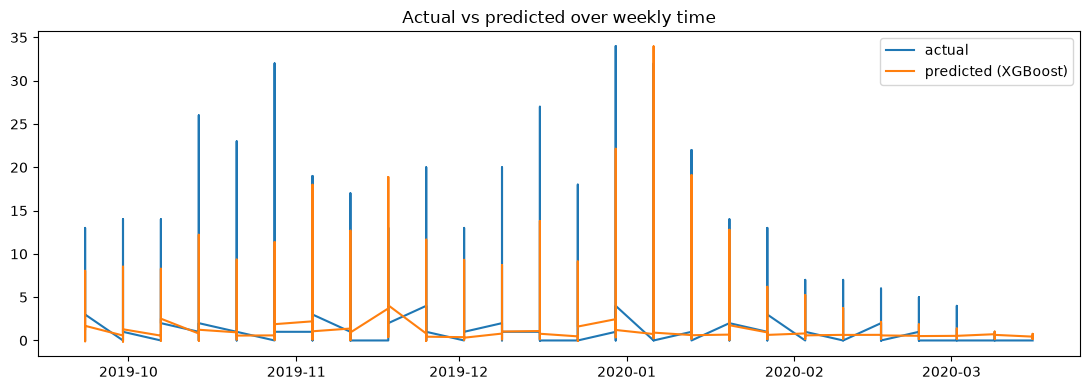

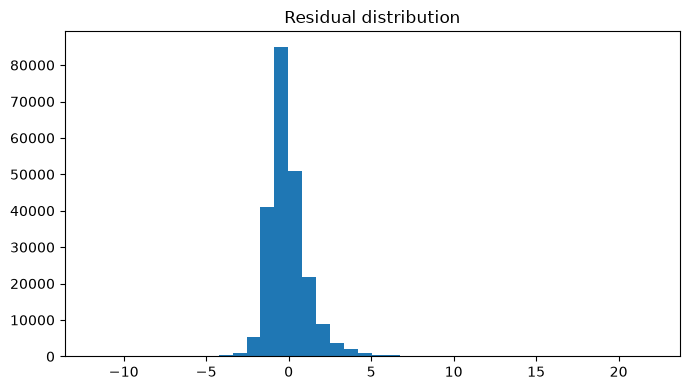

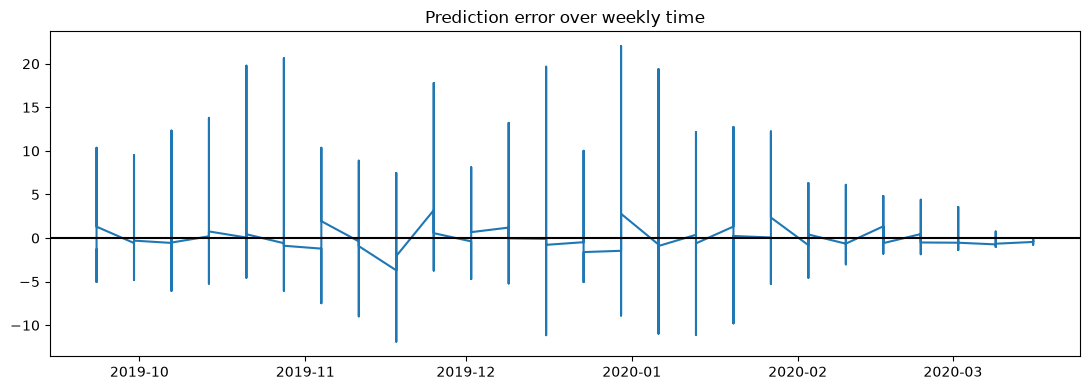

,importance
num__demand_rolling_mean_3,0.075060
num__demand_lag_1,0.056480
num__restock_past_1,0.031901
cat__category_maxi,0.018085
cat__season_SS17,0.017785
cat__shop_label_12,0.016627
num__demand_lag_3,0.016364
cat__fabric_frise,0.015016
num__calendar_week,0.014727
cat__fabric_silky satin,0.013671


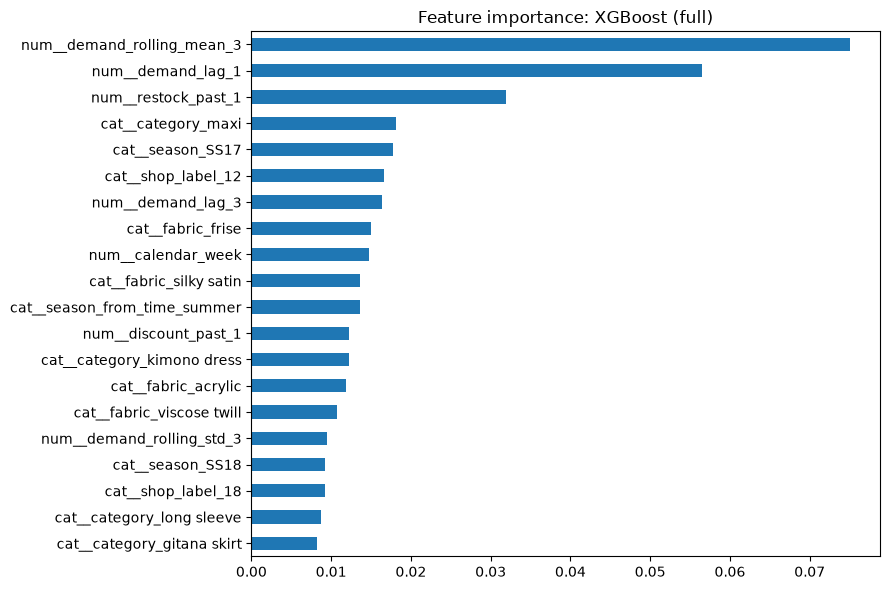

Conclusion: XGBoost was selected using validation WAPE. Test evaluation and test diagnostics run only when FINAL_EVALUATION=True with FAST_DEV_RUN=False.


In [11]:
if FINAL_EVALUATION:
    test_pred=np.asarray(test_predictions[best_name])
    plot_df=test[['time']].copy(); plot_df['actual']=yt.to_numpy(); plot_df['predicted']=test_pred; plot_df=plot_df.sort_values('time')
    fig,ax=plt.subplots(figsize=(11,4)); ax.plot(plot_df.time,plot_df.actual,label='actual'); ax.plot(plot_df.time,plot_df.predicted,label=f'predicted ({best_name})'); ax.legend(); ax.set_title('Actual vs predicted over weekly time'); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_demand_actual_vs_predicted.png',dpi=150); plt.show()
    resid=plot_df.actual-plot_df.predicted
    fig,ax=plt.subplots(figsize=(7,4)); ax.hist(resid,bins=40); ax.set_title('Residual distribution'); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_demand_residual_distribution.png',dpi=150); plt.show()
    fig,ax=plt.subplots(figsize=(11,4)); ax.plot(plot_df.time,resid); ax.axhline(0,color='black'); ax.set_title('Prediction error over weekly time'); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_demand_error_over_time.png',dpi=150); plt.show()
else:
    print('Development run: test-based diagnostic figures were not generated.')

if best_name in fitted and hasattr(fitted[best_name].named_steps['model'],'feature_importances_'):
    best=fitted[best_name]
    names=best.named_steps['prep'].get_feature_names_out(); assert any('season_from_time' in name for name in names)
    all_imp=pd.Series(best.named_steps['model'].feature_importances_,index=names).sort_values(ascending=False)
    imp=all_imp.head(20); display(imp.to_frame('importance'))
    all_imp.to_csv(METRIC_DIR/'demand_feature_importance.csv',header=['importance'])
    fig,ax=plt.subplots(figsize=(9,6)); imp.sort_values().plot.barh(ax=ax); ax.set_title(f'Feature importance: {best_name} ({RUN_TYPE})'); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_demand_feature_importance.png',dpi=150); plt.show()
print('Conclusion:',best_name,'was selected using validation WAPE. Test evaluation and test diagnostics run only when FINAL_EVALUATION=True with FAST_DEV_RUN=False.')